# RESULTS

In this file we are going to evaluate the results. We will start by checking the performance of each group of features regarding the predictions we achieve with all the combinations of them, and looking at what metrics each grup increases. Based on that we will define our final group of features, so our final model.

The last step will consist on evaluate this model by checking the feature importance, the shap values and finally showing some examples of the performance of the model, and the general performance in both the hard onset countries and the protracted ones. 

In [32]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, confusion_matrix
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from panelsplit.cross_validation import PanelSplit
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import ipywidgets as widgets
import joblib

In [33]:
# Define the exact path where the file was saved
file_path = "results/experiments_map.json"

# Open the file in read mode ('r') and load it
with open(file_path, "r", encoding="utf-8") as f:
    experiments_map = json.load(f)

experiments_map["Random Benchmark (Stratified)"] = "benchmark_random"
experiments_map["Optimal"] = "optimal"

# Perfect! Your dictionary is now fully recovered
print(f"Experiments map loaded successfully. Total experiments: {len(experiments_map)}")

Experiments map loaded successfully. Total experiments: 72


### 1. RESULTS ANALYSIS BASED ON FEATURES GROUPS

In [34]:
def evaluate_experiments(plots_filter, df_master, threshold_05=False, results_folder="results", experiments_map=None):
    """
    Evaluates ML experiments, plots 6 curves (Global, Protracted, Hard Onset),
    calculates subgroup metrics, and displays ONE single global legend at the bottom without overlapping.
    """
    comparison_results = []
    
    # Prepare the graphics
    fig, axes = plt.subplots(3, 2, figsize=(18, 35))
    ax_roc_glob, ax_pr_glob = axes[0]
    ax_roc_pro, ax_pr_pro = axes[1]
    ax_roc_hard, ax_pr_hard = axes[2]

    for name, prefix in experiments_map.items():
        if name not in plots_filter:
            continue

        pred_file = os.path.join(results_folder, f"{prefix}_predictions.csv")
        feat_file = os.path.join(results_folder, f"{prefix}_feature_importance.csv")
        
        if not os.path.exists(pred_file):
            continue
            
        print(f"Processing: {name}...")
        
        # Load predictions
        df_preds = pd.read_csv(pred_file)

        if 'Unnamed: 0' in df_preds.columns and 'Unnamed: 1' in df_preds.columns:
            df_preds = df_preds.rename(columns={'Unnamed: 0': 'iso3', 'Unnamed: 1': 'month'})
        
        if 'month' in df_preds.columns:
            df_preds['month'] = pd.to_datetime(df_preds['month'], errors='coerce')

        all_y_true = df_preds["y_true"]
        all_y_prob = df_preds["y_prob"]

        # Optimize threshold based on F1 score if not using 0.5
        if threshold_05:
            current_threshold = 0.5
        else:
            precisions, recalls, thresholds_pr = precision_recall_curve(all_y_true, all_y_prob)
            f1_scores = np.divide(
                2 * (precisions * recalls),
                (precisions + recalls),
                out=np.zeros_like(precisions),
                where=(precisions + recalls) != 0
            )
            best_idx = np.argmax(f1_scores[:-1])
            current_threshold = thresholds_pr[best_idx]

        df_preds['y_pred'] = (all_y_prob >= current_threshold).astype(int)

        # Global metrics
        f1 = f1_score(all_y_true, df_preds['y_pred'])
        prec = precision_score(all_y_true, df_preds['y_pred'], zero_division=0)
        rec = recall_score(all_y_true, df_preds['y_pred'])
        roc_auc = roc_auc_score(all_y_true, all_y_prob)
        num_features = len(pd.read_csv(feat_file)) if os.path.exists(feat_file) else 0

        # Subgroup metrics initialization
        pro_prec, pro_rec, pro_f1, pro_roc_auc = np.nan, np.nan, np.nan, np.nan
        hard_prec, hard_rec, hard_f1, hard_roc_auc = np.nan, np.nan, np.nan, np.nan
        has_subgroups = False
        
        if 'is_protracted' not in df_preds.columns:
            if 'iso3' in df_preds.columns and 'month' in df_preds.columns:
                df_preds = pd.merge(df_preds, df_master[['iso3', 'month', 'is_protracted']], on=['iso3', 'month'], how='inner')

        if 'is_protracted' in df_preds.columns and not df_preds['is_protracted'].isna().all():
            has_subgroups = True
        
        # Plotting ROC and PR curves
        fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
        ax_roc_glob.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
        
        prec_curve, rec_curve, _ = precision_recall_curve(all_y_true, all_y_prob)
        avg_prec = average_precision_score(all_y_true, all_y_prob)
        ax_pr_glob.plot(rec_curve, prec_curve, lw=2, label=f'{name} (AP = {avg_prec:.3f})')

        if has_subgroups:
            # Protracted crises
            pro_mask = df_preds['is_protracted'] == 1
            if pro_mask.sum() > 0:
                y_t_pro = df_preds.loc[pro_mask, 'y_true']
                y_p_pro = df_preds.loc[pro_mask, 'y_prob']
                y_pred_pro = df_preds.loc[pro_mask, 'y_pred']
                
                pro_prec = precision_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_rec = recall_score(y_t_pro, y_pred_pro, zero_division=0)
                pro_f1 = f1_score(y_t_pro, y_pred_pro, zero_division=0)
                
                if len(np.unique(y_t_pro)) > 1:
                    pro_roc_auc = roc_auc_score(y_t_pro, y_p_pro)
                    fpr_p, tpr_p, _ = roc_curve(y_t_pro, y_p_pro)
                    ax_roc_pro.plot(fpr_p, tpr_p, lw=2) 
                    
                    prec_p, rec_p, _ = precision_recall_curve(y_t_pro, y_p_pro)
                    ax_pr_pro.plot(rec_p, prec_p, lw=2)

            # Hard onset crises
            hard_mask = df_preds['is_protracted'] == 0
            if hard_mask.sum() > 0:
                y_t_hard = df_preds.loc[hard_mask, 'y_true']
                y_p_hard = df_preds.loc[hard_mask, 'y_prob']
                y_pred_hard = df_preds.loc[hard_mask, 'y_pred']
                
                hard_prec = precision_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_rec = recall_score(y_t_hard, y_pred_hard, zero_division=0)
                hard_f1 = f1_score(y_t_hard, y_pred_hard, zero_division=0)
                
                if len(np.unique(y_t_hard)) > 1:
                    hard_roc_auc = roc_auc_score(y_t_hard, y_p_hard)
                    fpr_h, tpr_h, _ = roc_curve(y_t_hard, y_p_hard)
                    ax_roc_hard.plot(fpr_h, tpr_h, lw=2)
                    
                    prec_h, rec_h, _ = precision_recall_curve(y_t_hard, y_p_hard)
                    ax_pr_hard.plot(rec_h, prec_h, lw=2)

        # Save results for comparison
        comparison_results.append({
            'Experiment': name,
            'Thr': round(current_threshold, 3),
            'Glob F1': round(f1, 3),
            'Glob P': round(prec, 3),
            'Glob R': round(rec, 3),
            'Glob AUC': round(roc_auc, 3),
            'Pro F1': round(pro_f1, 3) if pd.notna(pro_f1) else '-',
            'Pro P': round(pro_prec, 3) if pd.notna(pro_prec) else '-',
            'Pro R': round(pro_rec, 3) if pd.notna(pro_rec) else '-',
            'Pro AUC': round(pro_roc_auc, 3) if pd.notna(pro_roc_auc) else '-',
            'Hard F1': round(hard_f1, 3) if pd.notna(hard_f1) else '-',
            'Hard P': round(hard_prec, 3) if pd.notna(hard_prec) else '-',
            'Hard R': round(hard_rec, 3) if pd.notna(hard_rec) else '-',
            'Hard AUC': round(hard_roc_auc, 3) if pd.notna(hard_roc_auc) else '-',
            'Feats': num_features
        })


    plot_configs = [
        (ax_roc_glob, ax_pr_glob, 'GLOBAL'),
        (ax_roc_pro, ax_pr_pro, 'PROTRACTED CRISES (is_protracted = 1)'),
        (ax_roc_hard, ax_pr_hard, 'HARD ONSET CRISES (is_protracted = 0)')
    ]
    
    for ax_roc, ax_pr, title in plot_configs:
        ax_roc.plot([0, 1], [0, 1], color='navy', linestyle='--', alpha=0.5)
        ax_roc.set_xlim([0.0, 1.0])
        ax_roc.set_ylim([0.0, 1.05])
        ax_roc.set_title(f'{title}: ROC Curve', fontsize=14, fontweight='bold')
        ax_roc.set_xlabel('False Positive Rate', fontsize=11)
        ax_roc.set_ylabel('True Positive Rate', fontsize=11)
        ax_roc.grid(alpha=0.3)

        ax_pr.set_xlim([0.0, 1.0])
        ax_pr.set_ylim([0.0, 1.05])
        ax_pr.set_title(f'{title}: Precision-Recall Curve', fontsize=14, fontweight='bold')
        ax_pr.set_xlabel('Recall', fontsize=11)
        ax_pr.set_ylabel('Precision', fontsize=11)
        ax_pr.grid(alpha=0.3)

    handles, labels = ax_roc_glob.get_legend_handles_labels()
    
    plt.tight_layout(rect=[0, 0.25, 1, 1])
    
    fig.legend(
        handles, 
        labels, 
        loc='upper center',       
        bbox_to_anchor=(0.5, 0.23),
        ncol=3,                  
        fontsize=9, 
        frameon=True,
        facecolor='#f9f9f9',
        edgecolor='#d3d3d3'
    )

    plt.show()

    # Print final ranking of experiments based on Global F1 score
    if comparison_results:
        df_results = pd.DataFrame(comparison_results).sort_values(by='Glob F1', ascending=False)
        print("\n" + "#"*160)
        print("FINAL RANKING (SORTED BY GLOBAL F1)".center(160))
        print("#"*160)
        print(df_results.to_string(index=False))
    else:
        print("\nNo experiments were successfully loaded.")

All the available models that we have, and that we can check their performance are:

In [35]:
models = list(experiments_map.keys())

In [36]:
print(models)

['Signals (CERF)', 'INFORM', 'INFORM + Signals (CERF)', 'Risk Alerts', 'Risk Alerts + Signals (CERF)', 'Risk Alerts + INFORM', 'Risk Alerts + INFORM + Signals (CERF)', 'Risk Alerts BEST', 'Risk Alerts BEST + Signals (CERF)', 'Risk Alerts BEST + INFORM', 'Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact', 'Derived Humanitarian Impact + Signals (CERF)', 'Derived Humanitarian Impact + INFORM', 'Derived Humanitarian Impact + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts', 'Derived Humanitarian Impact + Risk Alerts + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts + INFORM', 'Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST', 'Derived Humanitarian Impact + Risk Alerts BEST + Signals (CERF)', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM', 'Derived Humanitarian Impact + Risk Alerts BEST + INFORM + Signals (CERF)', 'Derived Humanitarian Impact BEST', 'Der

Plotting the comparison of all the possible combinations:

Processing: Signals (CERF)...
Processing: INFORM...
Processing: INFORM + Signals (CERF)...
Processing: Risk Alerts...
Processing: Risk Alerts + Signals (CERF)...
Processing: Risk Alerts + INFORM...
Processing: Risk Alerts + INFORM + Signals (CERF)...
Processing: Risk Alerts BEST...
Processing: Risk Alerts BEST + Signals (CERF)...
Processing: Risk Alerts BEST + INFORM...
Processing: Risk Alerts BEST + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact...
Processing: Derived Humanitarian Impact + Signals (CERF)...
Processing: Derived Humanitarian Impact + INFORM...
Processing: Derived Humanitarian Impact + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts...
Processing: Derived Humanitarian Impact + Risk Alerts + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM...
Processing: Derived Humanitarian Impact + Risk Alerts + INFORM + Signals (CERF)...
Processing: Derived Humanitarian Impact + Risk Alerts BEST...
Pro

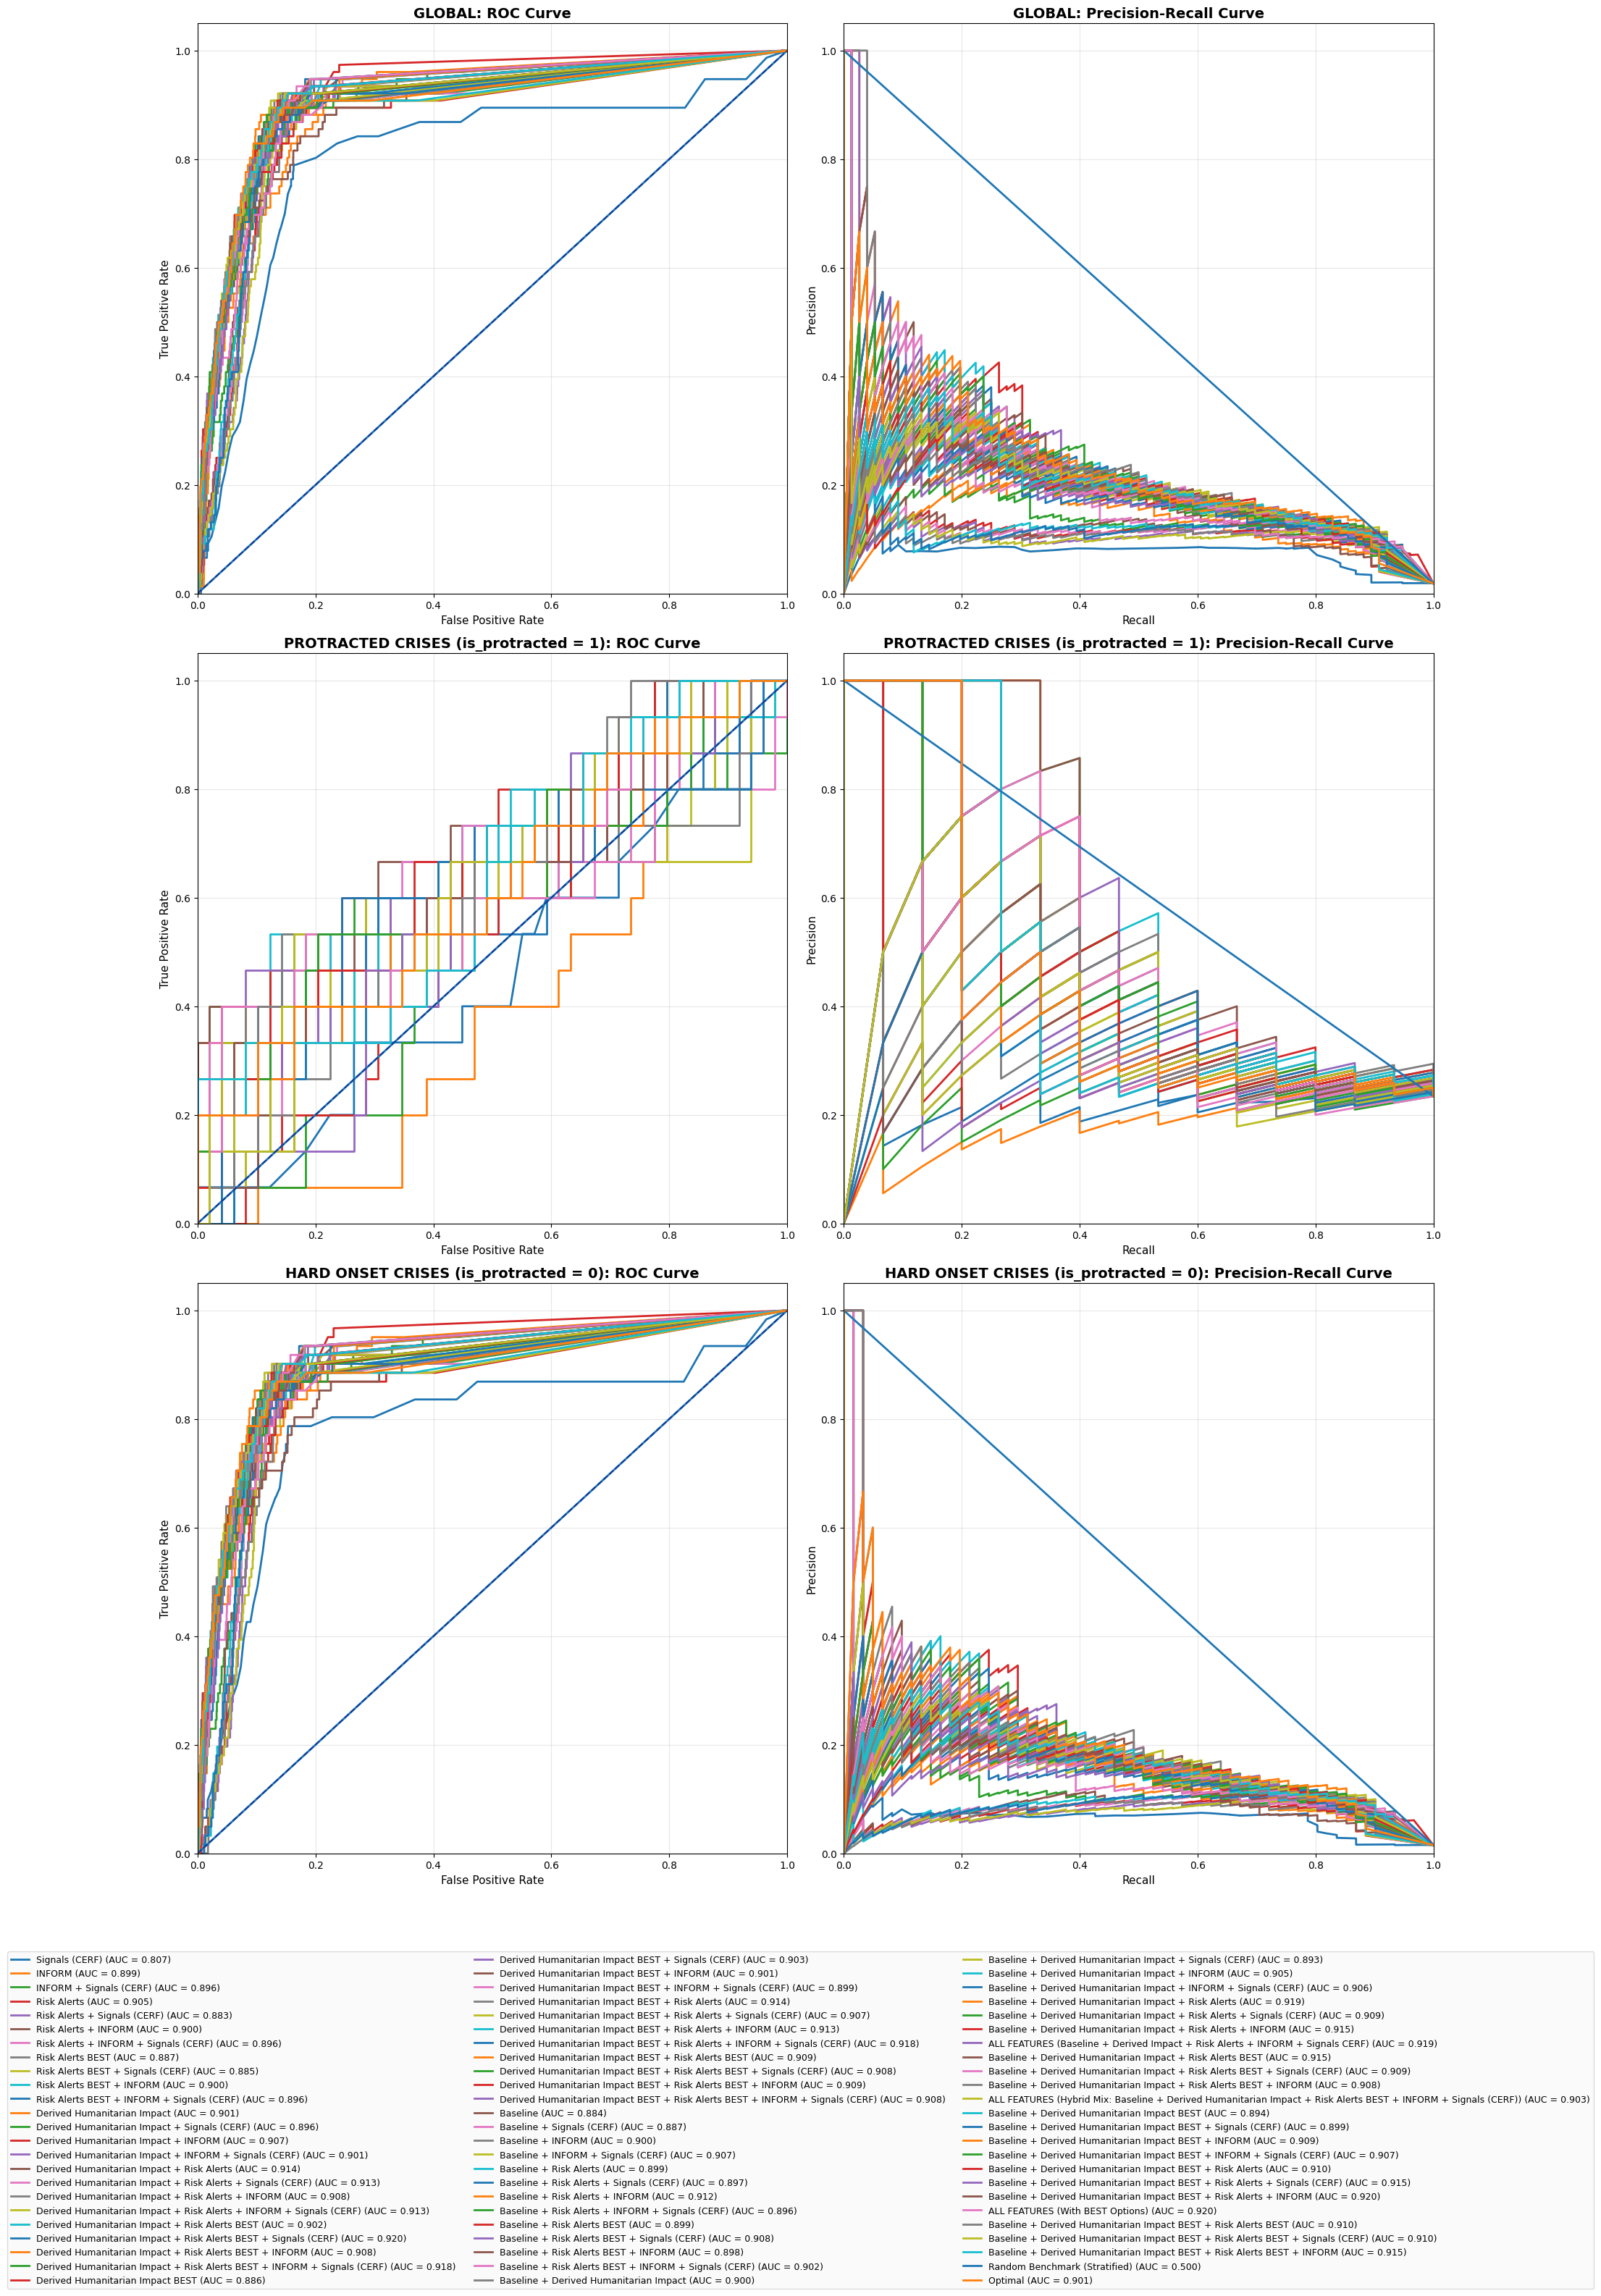


################################################################################################################################################################
                                                              FINAL RANKING (SORTED BY GLOBAL F1)                                                               
################################################################################################################################################################
                                                                                                    Experiment   Thr  Glob F1  Glob P  Glob R  Glob AUC  Pro F1  Pro P  Pro R  Pro AUC  Hard F1  Hard P  Hard R  Hard AUC  Feats
                                                                          Derived Humanitarian Impact + INFORM 0.791    0.338   0.383   0.303     0.907   0.435  0.625  0.333    0.656    0.319   0.346   0.295     0.898     35
                                                             Deriv

In [37]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

if 'iso3' not in df_original.columns:
    df_original = df_original.reset_index()
if 'month' in df_original.columns:
    df_original['month'] = pd.to_datetime(df_original['month'], errors='coerce')


evaluate_experiments(
    plots_filter=models, 
    df_master=df_original,
    threshold_05=False, 
    experiments_map=experiments_map
)

### 2. CHOOSING THE FINAL MODEL (FINAL GROUP OF FEATURES)

We have decided that our final model is the one containing the following features. The thing is that we have seen that INFORM, Derived Humanitarian Impact, and Cerf Signals are super usefull (the first two models have two out of these 3 grupos of features). Also we see that the one with Derived Humanitarian Impact + INFORM has more precision, and the one with Derived Humanitarian Impact BEST + Signals (CERF) have more recall, so we think that joining them has to be usefull. Also, regarding the risk variables, we see that including risk variables in general increases the recall, which is our main target, so even though we are not ading all the blok because it causes curse of dimensionality, we think that adding the main two variables is going to help the model increase the recall.

In [38]:
best_features_derived_humanitarian_impact =  ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals =  ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']

FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

In [39]:
ruta_parquet = "../data_clean/final_data.parquet" 
df_original = pd.read_parquet(ruta_parquet)

In [40]:
RESULTS_FOLDER = "results"
FILE_PREFIX = "rf_baseline"

MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

os.makedirs(RESULTS_FOLDER, exist_ok=True)

# DATA PREPARATION FOR CROSS-VALIDATION
df_cv_prep = df_original.copy()

# Hide the latest 2 months per country to handle target reporting lag
last_2_months_mask = df_cv_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_cv_prep[TARGET_COL] = df_cv_prep[TARGET_COL].astype(float)
df_cv_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

# Keep only the needed columns and drop rows with missing data (NaNs)
cols_to_keep = FINAL_FEATURES + [TARGET_COL]
df_cv_clean = df_cv_prep[cols_to_keep].dropna()

# Separate features, targets, and time/country trackers
X_cv = df_cv_clean[FINAL_FEATURES]
y_cv = df_cv_clean[TARGET_COL]
periods_cv = df_cv_clean.index.get_level_values('month')

# CROSS-VALIDATION LOOP (PANEL SPLIT)
print("\n" + "="*60)
print(f"RUNNING CROSS-VALIDATION (Features count: {len(FINAL_FEATURES)})")
print("="*60)

panel_split = PanelSplit(periods=periods_cv, n_splits=24, test_size=1, gap=1)
clf_cv = RandomForestClassifier(**MODEL_PARAMS)

all_y_true = []
all_y_prob = []
all_iso3 = []
all_months = []

for train_idx, test_idx in panel_split.split(X_cv):
    # Slice arrays using iloc positionally
    X_train, X_test = X_cv.iloc[train_idx], X_cv.iloc[test_idx]
    y_train, y_test = y_cv.iloc[train_idx], y_cv.iloc[test_idx]
    
    # Train and predict out-of-sample probabilities
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    # Store results
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))

# OPTIMAL THRESHOLD OPTIMIZATION & SAVING PREDICTIONS

# Calculate the F1-maximizing threshold over all combined validation outputs
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

# Create the final predictions DataFrame
df_preds_final = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob
})

# Map binary predictions using the optimized threshold
df_preds_final['optimal_threshold'] = best_threshold
df_preds_final['y_pred'] = (df_preds_final['y_prob'] >= best_threshold).astype(int)

# Export predictions to CSV
pred_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_predictions.csv")
df_preds_final.to_csv(pred_path, index=False)

print(f"Optimal Threshold calculated: {best_threshold:.4f}")
print(f"Saved predictions dataframe to: {pred_path}")

# EXPORT FEATURE IMPORTANCE FROM CV
df_feat = pd.DataFrame({
    'feature': X_cv.columns,
    'importance': clf_cv.feature_importances_
}).sort_values(by='importance', ascending=False)

feat_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_feature_importance.csv")
df_feat.to_csv(feat_path, index=False)
print(f"Saved feature importance matrix to: {feat_path}")

# Print performance overview
final_f1 = f1_score(all_y_true, df_preds_final['y_pred'])
final_auc = roc_auc_score(all_y_true, all_y_prob)
print(f"CV Metrics -> F1 (at optimal thr): {final_f1:.3f} | AUC: {final_auc:.3f}")

# TRAINING FINAL MODEL (100% OF HISTORICAL DATA)
print("\n" + "="*60)
print("TRAINING FINAL PRODUCTION MODEL (100% of historical data)")
print("="*60)

df_final_prep = df_original.copy()

# Apply the same 2-month reporting lag mask
last_2_months_mask_full = df_final_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_final_prep[TARGET_COL] = df_final_prep[TARGET_COL].astype(float)
df_final_prep.loc[last_2_months_mask_full, TARGET_COL] = np.nan

# Clean rows
df_final_clean = df_final_prep[FINAL_FEATURES + [TARGET_COL]].dropna()

X_full = df_final_clean[FINAL_FEATURES]
y_full = df_final_clean[TARGET_COL]

# Fit final model instance
model_final = RandomForestClassifier(**MODEL_PARAMS)
model_final.fit(X_full, y_full)

model_path = os.path.join(RESULTS_FOLDER, f"{FILE_PREFIX}_final_model.joblib")
joblib.dump(model_final, model_path)

print(f"Final model successfully trained on all {len(X_full)} historical panel samples.")
print("The 'model_final' object is ready for SHAP values extraction.")


RUNNING CROSS-VALIDATION (Features count: 25)


KeyboardInterrupt: 

Before stablishing the final model, we will do some hyperparameter tunning to see if we can improve the model:

In [ ]:
def prepare_final_data(df, features_to_use, target_col='target_2m'):
    df_temp = df.copy()
    
    last_2_months_mask = df_temp.groupby('iso3').cumcount(ascending=False) < 2
    df_temp[target_col] = df_temp[target_col].astype(float)
    df_temp.loc[last_2_months_mask, target_col] = np.nan

    df_model = df_temp.dropna(subset=features_to_use + [target_col])
    
    X = df_model[features_to_use]
    y = df_model[target_col]
    
    subgroups = df_model['is_protracted'] 
    
    return X, y, subgroups


X, y, subgroups = prepare_final_data(df_original, FINAL_FEATURES, TARGET_COL)
periods = X.index.get_level_values('month')


panel_split = PanelSplit(periods=periods, n_splits=24, test_size=1, gap=1)
cv_splits = list(panel_split.split(X))

# HYPERPARAMETER TUNING 
print("Starting Hyperparameter Tuning...")

# Define the hyperparameter search space
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10]
}

# Base model for RandomizedSearchCV
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# Aleatory search (more efficient than GridSearchCV) optimizing the F1-Score
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=9,           
    scoring='average_precision',        
    cv=cv_splits,        
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X, y)
best_params = random_search.best_params_

print(f"Best Parameters:\n{best_params}\n")

# Validation with the best hyperparameters
print("Evaluating the model with the optimal parameters...")

# Instanciamos el modelo con los hiperparámetros ganadores
clf_cv = RandomForestClassifier(**best_params, class_weight='balanced', random_state=42, n_jobs=-1)

all_y_true, all_y_prob, all_iso3, all_months, all_subgroups = [], [], [], [], []

for train_idx, test_idx in cv_splits:
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    clf_cv.fit(X_train, y_train)
    probs = clf_cv.predict_proba(X_test)[:, 1]
    
    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(X_test.index.get_level_values('iso3'))
    all_months.extend(X_test.index.get_level_values('month'))
    all_subgroups.extend(subgroups.iloc[test_idx].values)

df_eval = pd.DataFrame({
    'iso3': all_iso3,
    'month': all_months,
    'y_true': all_y_true,
    'y_prob': all_y_prob,
    'is_protracted': all_subgroups
})

# Compute the optimal threshold based on F1 score
precisions, recalls, thresholds = precision_recall_curve(df_eval['y_true'], df_eval['y_prob'])
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[np.argmax(f1_scores[:-1])]
best_f1 = f1_scores[best_idx]

# Asign predictions based on the best threshold
df_eval['y_pred'] = (df_eval['y_prob'] >= best_threshold).astype(int)
print(f"Best threshold: {best_threshold:.4f}")
print(f"F1-Score at optimal threshold: {best_f1:.4f}")

Starting Hyperparameter Tuning...
Fitting 24 folds for each of 9 candidates, totalling 216 fits
Best Parameters:
{'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'sqrt', 'max_depth': 15}

Evaluating the model with the optimal parameters...
Best threshold: 0.6679
F1-Score at optimal threshold: 0.3194


As we can see, by doing hyperparameter tunning we don't achieve a better performance, so we will define our model as the one with the default parameters.

### 3. EVALUATING THE FINAL MODEL

We add the predictions to the original dataset, to create a finals dataset with all the information:

In [ ]:
min_month = df_preds_final['month'].min()

df_original_test = df_original[df_original.index.get_level_values('month') >= min_month].copy()
df_preds_indexed = df_preds_final.set_index(['iso3', 'month'])
df_final_test = df_original_test.join(df_preds_indexed, how='left')

# Quick check
print(f"Test period starts at: {min_month}")
print(f"Rows in df_original_test: {len(df_original_test)}")
print(f"Rows in df_final_test: {len(df_final_test)}")

Test period starts at: 2024-03-01 00:00:00
Rows in df_original_test: 4576
Rows in df_final_test: 4576


#### 3.1 METRICS EVALUATION

In [ ]:
def print_subgroup_metrics(df):
    # Drop rows without predictions or true values
    df_clean = df.dropna(subset=['y_true', 'y_pred', 'y_prob']).copy()
    
    if df_clean.empty:
        print("No valid predictions to evaluate.")
        return

    thr = df_clean['optimal_threshold'].iloc[0]
    print(f" Optimal Threshold: {thr:.3f}\n" + "-"*50)
    
    subsets = {
        'GLOBAL': df_clean,
        'PROTRACTED (is_protracted = 1)': df_clean[df_clean['is_protracted'] == 1],
        'HARD ONSET (is_protracted = 0)': df_clean[df_clean['is_protracted'] == 0]
    }
    
    for name, sub_df in subsets.items():
        if len(sub_df) == 0: continue
        y_t = sub_df['y_true']
        y_p = sub_df['y_pred']
        y_prob = sub_df['y_prob']
        
        f1 = f1_score(y_t, y_p, zero_division=0)
        prec = precision_score(y_t, y_p, zero_division=0)
        rec = recall_score(y_t, y_p, zero_division=0)
        auc = roc_auc_score(y_t, y_prob) if len(np.unique(y_t)) > 1 else np.nan
        
        print(f"{name}:")
        print(f"   F1-Score: {f1:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | AUC: {auc:.3f}\n")

print_subgroup_metrics(df_final_test)

 Optimal Threshold: 0.785
--------------------------------------------------
GLOBAL:
   F1-Score: 0.338 | Precision: 0.333 | Recall: 0.342 | AUC: 0.906

PROTRACTED (is_protracted = 1):
   F1-Score: 0.417 | Precision: 0.556 | Recall: 0.333 | AUC: 0.600

HARD ONSET (is_protracted = 0):
   F1-Score: 0.323 | Precision: 0.304 | Recall: 0.344 | AUC: 0.897



#### 3.2 FEATURE IMPORTANCE AND SHAP VALUES

In [ ]:
df_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_final.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Feature importance:")
display(df_importance)

Feature importance:


,feature,importance
0,disp_6m_avg,0.177658
24,risk_12,0.117505
6,fat_6m_avg,0.106296
2,disp_3m_avg,0.089753
3,fatalities_lag1,0.079625
23,risk_3,0.071177
5,fat_3m_avg,0.058253
1,rolling_3m_displacements,0.047094
15,INFORM,0.045878
8,fatalities_lag2,0.031927


Computing SHAP values...
New SHAP format detected (3D Array).
Generating Summary Plot...


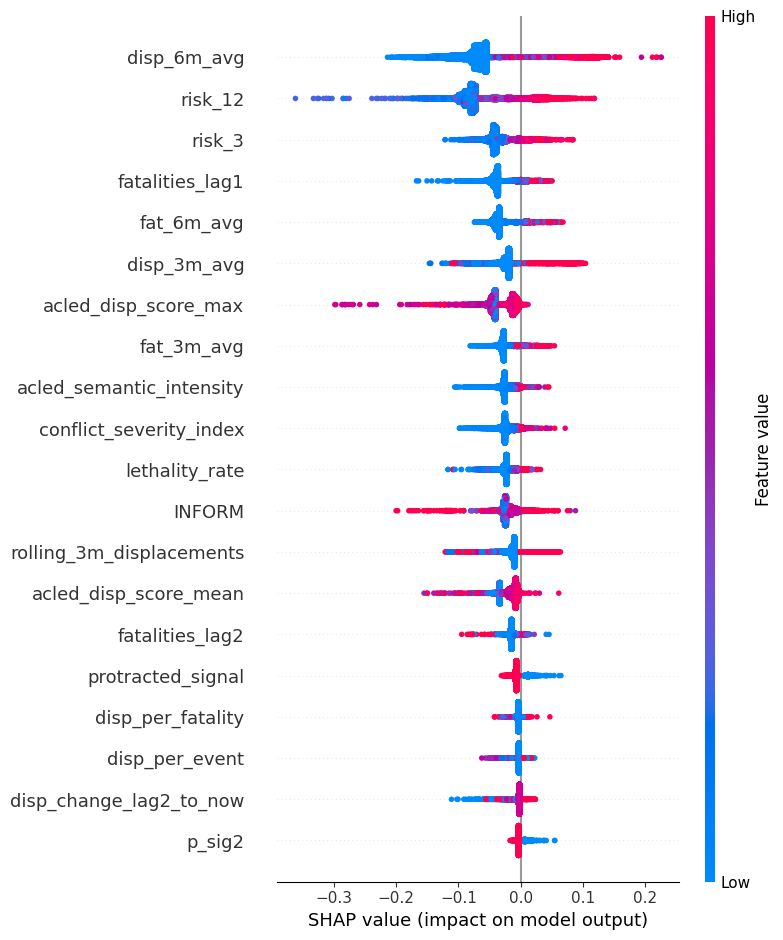

In [ ]:
explainer = shap.TreeExplainer(model_final)

# Compute the SHAP values for your matrix X
print("Computing SHAP values...")
shap_values = explainer.shap_values(X)

# Extract the positive class (1) safely
if isinstance(shap_values, list):
    print("Old SHAP format detected (List of arrays).")
    shap_values_positiva = shap_values[1]
elif isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    print("New SHAP format detected (3D Array).")
    shap_values_positiva = shap_values[:, :, 1]
else:
    print("Old 2D format detected.")
    shap_values_positiva = shap_values

# Plotting the Summary Plot 
print("Generating Summary Plot...")
shap.summary_plot(shap_values_positiva, X)

#### 3.3 SHOWING EXAMPLES OF THE RESULTS

In [ ]:
# Drop rows where we don't have predictions or true values
df_evaluation = df_final_test.dropna(subset=['y_true', 'y_pred'])

print("FALSE POSITIVES:")
print(len(df_evaluation[(df_evaluation['y_pred'] == 1) & (df_evaluation['y_true'] == 0)]))

print("FALSE NEGATIVES:")
print(len(df_evaluation[(df_evaluation['y_pred'] == 0) & (df_evaluation['y_true'] == 1)]))

print("\n\n================ METRICS REPORT ================\n")
print(classification_report(df_evaluation['y_true'], df_evaluation['y_pred']))

FALSE POSITIVES:
52
FALSE NEGATIVES:
50


================ METRICS REPORT ================

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      3984
         1.0       0.33      0.34      0.34        76

    accuracy                           0.97      4060
   macro avg       0.66      0.66      0.66      4060
weighted avg       0.98      0.97      0.98      4060



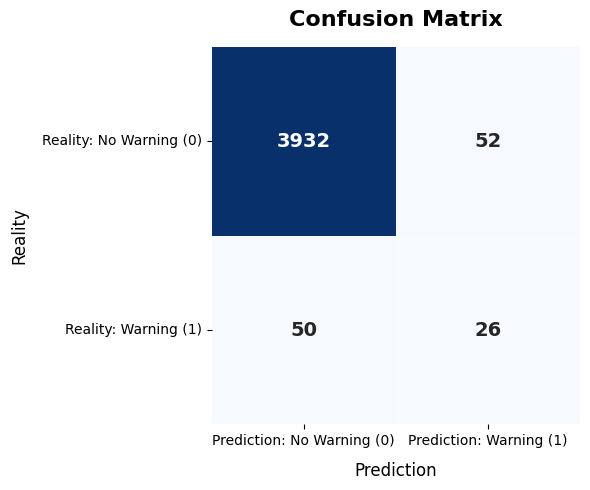

In [ ]:
# Comput the confusion matrix
cm = confusion_matrix(df_evaluation['y_true'], df_evaluation['y_pred'])


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Prediction: No Warning (0)', 'Prediction: Warning (1)'],
            yticklabels=['Reality: No Warning (0)', 'Reality: Warning (1)'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Prediction', fontsize=12, labelpad=10)
plt.ylabel('Reality', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
df_final_test.reset_index(inplace=True)

In [ ]:
def plot_country(country):
    country_df = df_final_test[df_final_test['iso3'] == country].sort_values('month').copy()
    
    # Normalize all variables to 0-1
    for col in ['fatalities', 'monthly_displacement', 'event_count']:
        max_val = country_df[col].max()
        country_df[col + '_norm'] = country_df[col] / max_val if max_val > 0 else 0

    fig, ax1 = plt.subplots(figsize=(14, 6))
    fig.suptitle(f'{country} — Multi-Signal Overview (normalized)', fontsize=13)
    
    ax1.plot(country_df['month'], country_df['fatalities_norm'],
             color='firebrick', linewidth=1.5, label='Fatalities (norm)')
    ax1.plot(country_df['month'], country_df['monthly_displacement_norm'],
             color='purple', linewidth=1.5, label='Displacement (norm)')
    ax1.plot(country_df['month'], country_df['event_count_norm'],
             color='gray', linewidth=1, alpha=0.7, label='Event count (norm)')
    ax1.plot(country_df['month'], country_df['risk_3'],
             color='black', linewidth=1.5, linestyle='--', label='Risk_3')
    ax1.plot(country_df['month'], country_df['INFORM'] / 10,
             color='steelblue', linewidth=1.5, linestyle=':', label='INFORM (norm)')
    

    # True Positives (TP: pred=1 i true=1) -> Green dashed
    true_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 1)]['month']
    for month in true_pos:
        ax1.axvline(x=month, color='green', alpha=0.8, linewidth=2, linestyle='--', label='TP (Encert Crític)')

    # False Positives (FP: pred=1 i true=0) -> Orange dashed
    false_pos = country_df[(country_df['y_pred'] == 1) & (country_df['y_true'] == 0)]['month']
    for month in false_pos:
        ax1.axvline(x=month, color='darkorange', alpha=0.8, linewidth=2, linestyle='--', label='FP (Falsa Alarma)')

    # False Negatives (FN: pred=0 i true=1) -> Red dashed
    false_neg = country_df[(country_df['y_pred'] == 0) & (country_df['y_true'] == 1)]['month']
    for month in false_neg:
        ax1.axvline(x=month, color='red', alpha=0.8, linewidth=2, linestyle='--', label='FN (Crisi no detectada)')

    ax1.set_ylim(0, 1.1)
    ax1.set_ylabel('Normalized value (0-1)')
    ax1.set_xlabel('Month')

    # Allocation-eligible 
    eligible = country_df[country_df['allocation-eligible'] == 1]['month']
    for month in eligible:
        ax1.axvline(x=month, color='red', alpha=0.1, linewidth=15, label='Allocation Eligible')

    # HDX alerts
    hdx_medium = country_df[country_df['hdx_alert_Medium concern'] == True]['month']
    hdx_high = country_df[country_df['hdx_alert_High concern'] == True]['month']
    ax1.scatter(hdx_medium, [1.05]*len(hdx_medium), color='orange', s=60, zorder=5, label='HDX Medium')
    ax1.scatter(hdx_high, [1.05]*len(hdx_high), color='red', s=60, zorder=5, label='HDX High')

    # Delete duplicate legend entries
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.show()

countries = sorted(df_final_test['iso3'].unique().tolist())
dropdown = widgets.Dropdown(options=countries, value='AFG', description='Country:')
widgets.interact(plot_country, country=dropdown)

interactive(children=(Dropdown(description='Country:', options=('AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS…

<function __main__.plot_country(country)>

FALTA LA GRAFICA COMPARANDOLO CON LO DE LAS CERF ALLOCATIONS QUE ESTAN EN CLEAN DATA EN CERF_CLEAN?! SERIA MEJOR HACER LA COMPARACION AL PRINCIPIO CON LO TEORICO, NO AHORA PORQUE LAS `REDICCIONES SON EN GENERAL MALAS?

LO DE LOS FALSOS NEGATIVO MIRAR QUALES SON O ALGO ASI?

#### 3.4 ROBUSTNESS CHECKS

To measure heterogeneity, that is, how our model perfoms in a different context, we will perform 3 robustness checks: (1) sepaarte blocks, (2)XG Boost and (3)Continents

### 1.Separate blocks

In [ ]:
# ============================================================
# ROBUSTNESS CHECK: Run the final model separately for each
# block that makes up FINAL_FEATURES, with Global/Protracted/Hard Onset breakdown
# ============================================================

best_features_derived_humanitarian_impact = ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals = ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']
FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

blocks_to_test = {
    "Derived Humanitarian Impact BEST": best_features_derived_humanitarian_impact,
    "INFORM": ["INFORM"],
    "CERF Signals": features_cerf_signals,
    "Risk (risk_3 + risk_12)": ["risk_3", "risk_12"],
    "FINAL_FEATURES (all combined)": FINAL_FEATURES,
}

MODEL_PARAMS = {
    'n_estimators': 200,
    'max_depth': 10,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1
}

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    """Returns F1, Precision, Recall, AUC for a given subset."""
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    fp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3), "AUC": round(auc, 3)}

robustness_results = []

for block_name, feature_list in blocks_to_test.items():

    print("\n" + "="*60)
    print(f"BLOCK: {block_name} ({len(feature_list)} features)")
    print("="*60)

    df_prep = df_original.copy()

    last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
    df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
    df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

    cols_to_keep = feature_list + [TARGET_COL, 'is_protracted']
    df_clean = df_prep[cols_to_keep].dropna(subset=feature_list + [TARGET_COL])

    X_block = df_clean[feature_list]
    y_block = df_clean[TARGET_COL]
    protracted_block = df_clean['is_protracted']
    periods_block = df_clean.index.get_level_values('month')

    panel_split = PanelSplit(periods=periods_block, n_splits=24, test_size=1, gap=1)
    clf_block = RandomForestClassifier(**MODEL_PARAMS)

    all_y_true, all_y_prob, all_protracted = [], [], []

    for train_idx, test_idx in panel_split.split(X_block):
        X_train, X_test = X_block.iloc[train_idx], X_block.iloc[test_idx]
        y_train, y_test = y_block.iloc[train_idx], y_block.iloc[test_idx]
        prot_test = protracted_block.iloc[test_idx]

        clf_block.fit(X_train, y_train)
        probs = clf_block.predict_proba(X_test)[:, 1]

        all_y_true.extend(y_test.values)
        all_y_prob.extend(probs)
        all_protracted.extend(prot_test.values)

    all_y_true = np.array(all_y_true)
    all_y_prob = np.array(all_y_prob)
    all_protracted = np.array(all_protracted)

    # Optimal threshold by F1 (computed on GLOBAL, same as main model)
    precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
    f1_scores = np.divide(
        2 * (precisions * recalls),
        (precisions + recalls),
        out=np.zeros_like(precisions),
        where=(precisions + recalls) != 0
    )
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    all_y_pred = (all_y_prob >= best_threshold).astype(int)

    # GLOBAL
    global_metrics = compute_subgroup_metrics(all_y_true, all_y_prob, all_y_pred)
    print(f"GLOBAL: F1={global_metrics['F1']} | P={global_metrics['Precision']} | R={global_metrics['Recall']} | AUC={global_metrics['AUC']}")

    # PROTRACTED (is_protracted == 1)
    mask_prot = all_protracted == 1
    prot_metrics = compute_subgroup_metrics(all_y_true[mask_prot], all_y_prob[mask_prot], all_y_pred[mask_prot])
    print(f"PROTRACTED: F1={prot_metrics['F1']} | P={prot_metrics['Precision']} | R={prot_metrics['Recall']} | AUC={prot_metrics['AUC']}")

    # HARD ONSET (is_protracted == 0)
    mask_hard = all_protracted == 0
    hard_metrics = compute_subgroup_metrics(all_y_true[mask_hard], all_y_prob[mask_hard], all_y_pred[mask_hard])
    print(f"HARD ONSET: F1={hard_metrics['F1']} | P={hard_metrics['Precision']} | R={hard_metrics['Recall']} | AUC={hard_metrics['AUC']}")
    print(f"Optimal Threshold: {best_threshold:.3f}")

    robustness_results.append({
        "Block": block_name,
        "N_Features": len(feature_list),
        "Threshold": round(best_threshold, 3),
        "Glob_F1": global_metrics["F1"], "Glob_P": global_metrics["Precision"], "Glob_R": global_metrics["Recall"], "Glob_AUC": global_metrics["AUC"],
        "Prot_F1": prot_metrics["F1"], "Prot_P": prot_metrics["Precision"], "Prot_R": prot_metrics["Recall"], "Prot_AUC": prot_metrics["AUC"],
        "Hard_F1": hard_metrics["F1"], "Hard_P": hard_metrics["Precision"], "Hard_R": hard_metrics["Recall"], "Hard_AUC": hard_metrics["AUC"],
    })

df_robustness = pd.DataFrame(robustness_results)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
display(df_robustness)

df_robustness.to_csv(os.path.join(RESULTS_FOLDER, "robustness_by_block.csv"), index=False)


BLOCK: Derived Humanitarian Impact BEST (15 features)
GLOBAL: F1=0.312 | P=0.298 | R=0.329 | AUC=0.886
PROTRACTED: F1=0.429 | P=0.462 | R=0.4 | AUC=0.61
HARD ONSET: F1=0.288 | P=0.268 | R=0.311 | AUC=0.874
Optimal Threshold: 0.755

BLOCK: INFORM (1 features)
GLOBAL: F1=0.232 | P=0.158 | R=0.434 | AUC=0.851
PROTRACTED: F1=0.327 | P=0.235 | R=0.533 | AUC=0.436
HARD ONSET: F1=0.212 | P=0.143 | R=0.41 | AUC=0.853
Optimal Threshold: 0.821

BLOCK: CERF Signals (7 features)
GLOBAL: F1=0.153 | P=0.085 | R=0.789 | AUC=0.808
PROTRACTED: F1=0.329 | P=0.207 | R=0.8 | AUC=0.504
HARD ONSET: F1=0.135 | P=0.074 | R=0.787 | AUC=0.791
Optimal Threshold: 0.545

BLOCK: Risk (risk_3 + risk_12) (2 features)
GLOBAL: F1=0.204 | P=0.124 | R=0.566 | AUC=0.858
PROTRACTED: F1=0.333 | P=0.216 | R=0.733 | AUC=0.431
HARD ONSET: F1=0.18 | P=0.108 | R=0.525 | AUC=0.844
Optimal Threshold: 0.393

BLOCK: FINAL_FEATURES (all combined) (25 features)
GLOBAL: F1=0.338 | P=0.333 | R=0.342 | AUC=0.906
PROTRACTED: F1=0.417 | P

,Block,N_Features,Threshold,Glob_F1,Glob_P,Glob_R,Glob_AUC,Prot_F1,Prot_P,Prot_R,Prot_AUC,Hard_F1,Hard_P,Hard_R,Hard_AUC
0,Derived Humanitarian Impact BEST,15,0.755,0.312,0.298,0.329,0.886,0.429,0.462,0.400,0.610,0.288,0.268,0.311,0.874
1,INFORM,1,0.821,0.232,0.158,0.434,0.851,0.327,0.235,0.533,0.436,0.212,0.143,0.410,0.853
2,CERF Signals,7,0.545,0.153,0.085,0.789,0.808,0.329,0.207,0.800,0.504,0.135,0.074,0.787,0.791
3,Risk (risk_3 + risk_12),2,0.393,0.204,0.124,0.566,0.858,0.333,0.216,0.733,0.431,0.180,0.108,0.525,0.844
4,FINAL_FEATURES (all combined),25,0.785,0.338,0.333,0.342,0.906,0.417,0.556,0.333,0.600,0.323,0.304,0.344,0.897


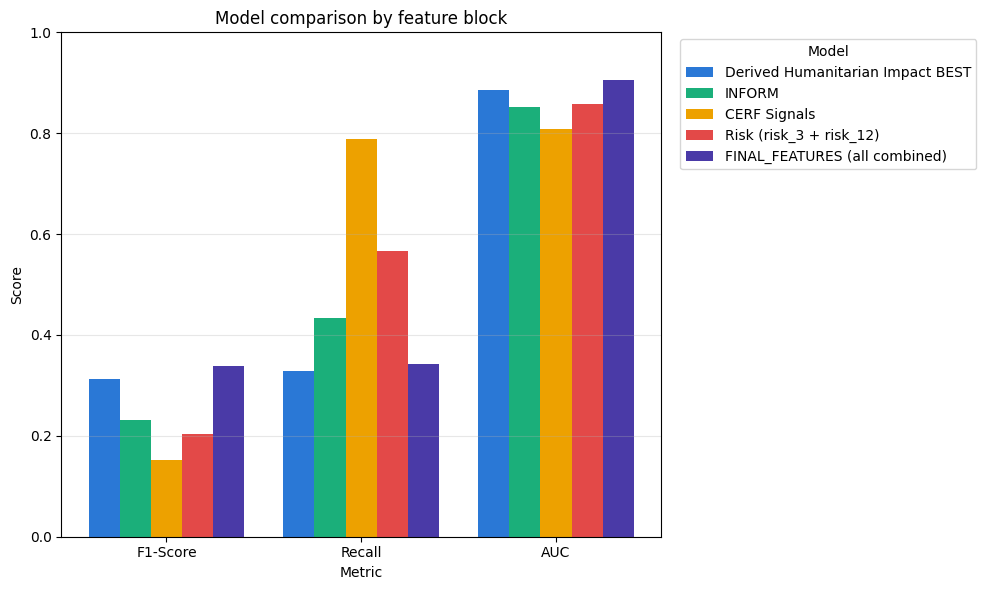

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Uses the df_robustness dataframe already generated by the robustness check code
metrics_to_plot = ['Glob_F1', 'Glob_R', 'Glob_AUC']
metric_labels = ['F1-Score', 'Recall', 'AUC']

models = df_robustness['Block'].tolist()
n_models = len(models)

# Custom color palette (one per model)
colors = ['#2a78d6', '#1baf7a', '#eda100', '#e34948', '#4a3aa7']

x = np.arange(len(metrics_to_plot))  # position of each metric group
width = 0.8 / n_models  # bar width, adjusted to the number of models

fig, ax = plt.subplots(figsize=(10, 6))

for i, model in enumerate(models):
    values = df_robustness.loc[df_robustness['Block'] == model, metrics_to_plot].values.flatten()
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model comparison by feature block')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/robustness_comparison.png', dpi=150)
plt.show()

### Key findings — robustness check by feature block

- **FINAL_FEATURES (combined, 25 features) achieves the best F1-score (0.338)** of all configurations tested, confirming that combining blocks outperforms any single block alone.
- **No individual block matches the combined model on F1**: Derived Humanitarian Impact BEST comes closest (0.312), followed by INFORM (0.232), Risk (0.204), and CERF Signals (0.153).
- **Recall and F1 trade off sharply across blocks**: CERF Signals alone reaches the highest recall (0.789) but the lowest F1 (0.153) and precision (0.085), confirming it generates many false positives when used in isolation.
- **Risk (risk_3 + risk_12) shows the same pattern**, with only 2 features it reaches 0.566 recall but just 0.204 F1 , useful as a recall booster within the combined model, not as an alone predictor.
- **Derived Humanitarian Impact BEST is the strongest individual block**, with the best precision (0.298) and F1 (0.312) among single blocks, and the highest AUC (0.886) of the four individual blocks.
- **AUC is high and stable across all blocks (0.808–0.906)**, including the weakest blocks by F1. This shows all blocks carry discriminative signal, but the choice of features still matters for translating that signal into the optimal-threshold F1.
- **Protracted vs. Hard Onset**: every block performs better on Protracted cases (F1 0.327–0.429) than on Hard Onset cases (F1 0.135–0.323), with the gap most pronounced in CERF Signals (Prot_F1 0.329 vs Hard_F1 0.135). This suggests hard onset crises remain harder to predict regardless of feature block.
- **FINAL_FEATURES leads on both subgroups**: Protracted F1 = 0.417 and Hard Onset F1 = 0.323 ,both the highest among all five models, reinforcing that the combined feature set generalizes better across crisis types, not just on the global metric.

In terms of robustness, this results suggests that the final model does not rely on a single block of variables to perform well. Each individual block on its own is not good (F1 ranging from 0.153 to 0.312), but the combined model outperforms even the best individual block (0.338 vs 0.312), showing that the blocks are complementary rather than redundant. This works like a panel of specialists rather than a single expert: each block captures a different angle of the problem, and their combined predictions compensate for each other's individual weaknesses. As a result, the model is less vulnerable to any single data source becoming unreliable or unavailable, since its performance does not hinge on one particular block.

### 2. XG BOOST

In [ ]:
# ============================================================
# ROBUSTNESS CHECK: XGBoost vs Random Forest on FINAL_FEATURES
# ============================================================

from xgboost import XGBClassifier

best_features_derived_humanitarian_impact = ['disp_6m_avg', 'rolling_3m_displacements', 'disp_3m_avg', 'fatalities_lag1', 'lethality_rate', 'fat_3m_avg', 'fat_6m_avg', 'acled_disp_score_max', 'fatalities_lag2', 'acled_disp_score_mean', 'conflict_severity_index', 'acled_semantic_intensity', 'disp_change_lag2_to_now', 'disp_per_event', 'disp_per_fatality']
features_cerf_signals = ['p_sig1', 'p_sig2', 'p_sig3', 'protracted_signal', 'h_sig1', 'h_sig2', 'hard_onset_signal']
FINAL_FEATURES = best_features_derived_humanitarian_impact + ["INFORM"] + features_cerf_signals + ["risk_3", "risk_12"]
TARGET_COL = 'target_2m'

# Default XGBoost params (no tuning) -- class imbalance handled via scale_pos_weight
df_prep = df_original.copy()
last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

cols_to_keep = FINAL_FEATURES + [TARGET_COL, 'is_protracted']
df_clean = df_prep[cols_to_keep].dropna(subset=FINAL_FEATURES + [TARGET_COL])

X_xgb = df_clean[FINAL_FEATURES]
y_xgb = df_clean[TARGET_COL]
protracted_xgb = df_clean['is_protracted']
periods_xgb = df_clean.index.get_level_values('month')

# scale_pos_weight mirrors class_weight='balanced' used in the Random Forest
scale_pos_weight = (y_xgb == 0).sum() / (y_xgb == 1).sum()

XGB_PARAMS = {
    'n_estimators': 200,
    'max_depth': 6,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'n_jobs': -1,
    'eval_metric': 'logloss'
}

panel_split = PanelSplit(periods=periods_xgb, n_splits=24, test_size=1, gap=1)
clf_xgb = XGBClassifier(**XGB_PARAMS)

all_y_true, all_y_prob, all_protracted = [], [], []

for train_idx, test_idx in panel_split.split(X_xgb):
    X_train, X_test = X_xgb.iloc[train_idx], X_xgb.iloc[test_idx]
    y_train, y_test = y_xgb.iloc[train_idx], y_xgb.iloc[test_idx]
    prot_test = protracted_xgb.iloc[test_idx]

    clf_xgb.fit(X_train, y_train)
    probs = clf_xgb.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_protracted.extend(prot_test.values)

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_protracted = np.array(all_protracted)

# Optimal threshold by F1 (same approach as the Random Forest model)
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(
    2 * (precisions * recalls),
    (precisions + recalls),
    out=np.zeros_like(precisions),
    where=(precisions + recalls) != 0
)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
all_y_pred = (all_y_prob >= best_threshold).astype(int)

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 1))
    fp = sum((np.array(y_pred) == 1) & (np.array(y_true) == 0))
    fn = sum((np.array(y_pred) == 0) & (np.array(y_true) == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3), "AUC": round(auc, 3)}

global_metrics = compute_subgroup_metrics(all_y_true, all_y_prob, all_y_pred)

mask_prot = all_protracted == 1
prot_metrics = compute_subgroup_metrics(all_y_true[mask_prot], all_y_prob[mask_prot], all_y_pred[mask_prot])

mask_hard = all_protracted == 0
hard_metrics = compute_subgroup_metrics(all_y_true[mask_hard], all_y_prob[mask_hard], all_y_pred[mask_hard])

print("="*60)
print(f"XGBOOST -- FINAL_FEATURES ({len(FINAL_FEATURES)} features)")
print("="*60)
print(f"Optimal Threshold: {best_threshold:.3f}")
print("-"*60)
print(f"GLOBAL: F1={global_metrics['F1']} | P={global_metrics['Precision']} | R={global_metrics['Recall']} | AUC={global_metrics['AUC']}")
print(f"PROTRACTED: F1={prot_metrics['F1']} | P={prot_metrics['Precision']} | R={prot_metrics['Recall']} | AUC={prot_metrics['AUC']}")
print(f"HARD ONSET: F1={hard_metrics['F1']} | P={hard_metrics['Precision']} | R={hard_metrics['Recall']} | AUC={hard_metrics['AUC']}")

df_xgb_results = pd.DataFrame([{
    "Model": "XGBoost (default)",
    "N_Features": len(FINAL_FEATURES),
    "Threshold": round(best_threshold, 3),
    "Glob_F1": global_metrics["F1"], "Glob_P": global_metrics["Precision"], "Glob_R": global_metrics["Recall"], "Glob_AUC": global_metrics["AUC"],
    "Prot_F1": prot_metrics["F1"], "Prot_P": prot_metrics["Precision"], "Prot_R": prot_metrics["Recall"], "Prot_AUC": prot_metrics["AUC"],
    "Hard_F1": hard_metrics["F1"], "Hard_P": hard_metrics["Precision"], "Hard_R": hard_metrics["Recall"], "Hard_AUC": hard_metrics["AUC"],
}])

df_xgb_results.to_csv(os.path.join(RESULTS_FOLDER, "xgboost_final_features.csv"), index=False)
display(df_xgb_results)

XGBOOST -- FINAL_FEATURES (25 features)
Optimal Threshold: 0.009
------------------------------------------------------------
GLOBAL: F1=0.293 | P=0.199 | R=0.553 | AUC=0.879
PROTRACTED: F1=0.407 | P=0.282 | R=0.733 | AUC=0.57
HARD ONSET: F1=0.266 | P=0.18 | R=0.508 | AUC=0.87


,Model,N_Features,Threshold,Glob_F1,Glob_P,Glob_R,Glob_AUC,Prot_F1,Prot_P,Prot_R,Prot_AUC,Hard_F1,Hard_P,Hard_R,Hard_AUC
0,XGBoost (default),25,0.009,0.293,0.199,0.553,0.879,0.407,0.282,0.733,0.57,0.266,0.18,0.508,0.87


MODEL COMPARISON -- Random Forest vs XGBoost (FINAL_FEATURES)


,Model,N_Features,Threshold,F1,Precision,Recall,AUC
0,Random Forest,25,0.785,0.338,0.333,0.342,0.906
1,XGBoost,25,0.009,0.293,0.199,0.553,0.879


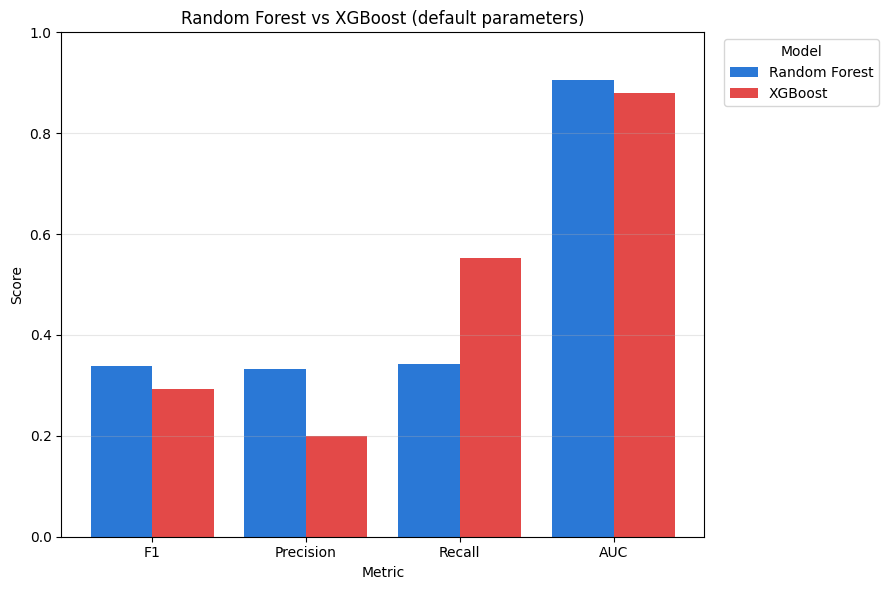

In [ ]:
# ============================================================
# COMPARISON TABLE AND CHART: Random Forest vs XGBoost
# (Global metrics, FINAL_FEATURES)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Build comparison table from the two results already computed:
# df_robustness (Random Forest, row "FINAL_FEATURES (all combined)")
# df_xgb_results (XGBoost, row "XGBoost (default)")

rf_row = df_robustness[df_robustness['Block'] == 'FINAL_FEATURES (all combined)'].iloc[0]
xgb_row = df_xgb_results.iloc[0]

df_model_comparison = pd.DataFrame([
    {
        "Model": "Random Forest",
        "N_Features": rf_row["N_Features"],
        "Threshold": rf_row["Threshold"],
        "F1": rf_row["Glob_F1"],
        "Precision": rf_row["Glob_P"],
        "Recall": rf_row["Glob_R"],
        "AUC": rf_row["Glob_AUC"],
    },
    {
        "Model": "XGBoost",
        "N_Features": xgb_row["N_Features"],
        "Threshold": xgb_row["Threshold"],
        "F1": xgb_row["Glob_F1"],
        "Precision": xgb_row["Glob_P"],
        "Recall": xgb_row["Glob_R"],
        "AUC": xgb_row["Glob_AUC"],
    },
])

print("="*60)
print("MODEL COMPARISON -- Random Forest vs XGBoost (FINAL_FEATURES)")
print("="*60)
display(df_model_comparison)

df_model_comparison.to_csv(os.path.join(RESULTS_FOLDER, "rf_vs_xgb_comparison.csv"), index=False)

# ============================================================
# CHART: grouped bar, metrics on X axis, model as legend
# ============================================================

metrics_to_plot = ['F1', 'Precision', 'Recall', 'AUC']
models = df_model_comparison['Model'].tolist()
n_models = len(models)

colors = ['#2a78d6', '#e34948']  # Random Forest = blue, XGBoost = red

x = np.arange(len(metrics_to_plot))
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(9, 6))

for i, model in enumerate(models):
    values = df_model_comparison.loc[df_model_comparison['Model'] == model, metrics_to_plot].values.flatten()
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, values, width, label=model, color=colors[i % len(colors)])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Random Forest vs XGBoost (default parameters)')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/rf_vs_xgb_comparison.png', dpi=150)
plt.show()

### XGBoost robustness check — Main Findings
Random Forest outperforms XGBoost on F1 (0.338 vs 0.293), precision (0.333 vs 0.199), and AUC (0.906 vs 0.879), both under default parameters with no tuning. XGBoost achieves higher recall (0.553 vs 0.342), but at the cost of far more false positives. XGBoost's optimal threshold is extremely low (0.009), indicating its predicted probabilities are poorly calibrated for this task without tuning , it needs almost any signal to flag a positive case.

**Implication for robustness**: the final model choice (Random Forest) is not arbitrary. Under the same conditions used to select the original model (default parameters, no tuning), it outperforms a reasonable alternative algorithm. This strengthens confidence that the model's performance reflects the underlying signal in the data, not a lucky choice of algorithm.

## (3) Continents

In [50]:
import pycountry_convert as pc

def iso3_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        continent_code = pc.country_alpha2_to_continent_code(iso2)
        continent_map = {
            'AF': 'Africa',
            'AS': 'Asia',
            'EU': 'Europe',
            'OC': 'Oceania',
        }
        # Both North and South America codes map to a single "America" region
        if continent_code in ('NA', 'SA'):
            return 'America'
        return continent_map.get(continent_code, 'Unknown')
    except:
        return 'Unknown'

iso3_list = df_original.index.get_level_values('iso3').unique()
continent_mapping = {iso3: iso3_to_continent(iso3) for iso3 in iso3_list}

continent_mapping['TLS'] = 'Asia'

df_original['continent'] = df_original.index.get_level_values('iso3').map(continent_mapping)

print(df_original.reset_index()[['iso3', 'continent']].drop_duplicates()['continent'].value_counts())

continent
Africa     52
Asia       48
Europe     39
America    29
Oceania     8
Name: count, dtype: int64


In [53]:
# Show example countries per region
df_regions = df_original.reset_index()[['iso3', 'continent']].drop_duplicates()

for region in df_regions['continent'].unique():
    countries = df_regions[df_regions['continent'] == region]['iso3'].tolist()
    print(f"{region} ({len(countries)} countries):")
    print(countries)
    print()

Asia (48 countries):
['AFG', 'ARE', 'ARM', 'AZE', 'BGD', 'BHR', 'BRN', 'BTN', 'CHN', 'CYP', 'GEO', 'IDN', 'IND', 'IRN', 'IRQ', 'ISR', 'JOR', 'JPN', 'KAZ', 'KGZ', 'KHM', 'KOR', 'KWT', 'LAO', 'LBN', 'LKA', 'MDV', 'MMR', 'MNG', 'MYS', 'NPL', 'OMN', 'PAK', 'PHL', 'PRK', 'PSE', 'QAT', 'SAU', 'SGP', 'SYR', 'THA', 'TJK', 'TKM', 'TLS', 'TUR', 'UZB', 'VNM', 'YEM']

Africa (52 countries):
['AGO', 'BDI', 'BEN', 'BFA', 'BWA', 'CAF', 'CIV', 'CMR', 'COD', 'COM', 'DJI', 'DZA', 'EGY', 'ERI', 'ETH', 'GAB', 'GHA', 'GIN', 'GMB', 'GNB', 'GNQ', 'KEN', 'LBR', 'LBY', 'LSO', 'MAR', 'MDG', 'MLI', 'MOZ', 'MRT', 'MUS', 'MWI', 'NAM', 'NER', 'NGA', 'RWA', 'SDN', 'SEN', 'SLE', 'SOM', 'SSD', 'STP', 'SWZ', 'SYC', 'TCD', 'TGO', 'TUN', 'TZA', 'UGA', 'ZAF', 'ZMB', 'ZWE']

Europe (39 countries):
['ALB', 'AUT', 'BEL', 'BGR', 'BIH', 'BLR', 'CHE', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA', 'GBR', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ITA', 'LTU', 'LUX', 'LVA', 'MDA', 'MKD', 'MLT', 'MNE', 'NLD', 'NOR', 'POL', 'PRT', 'ROU

In [51]:
# Proportion of class 1 (target_2m) by region
df_check = df_original.reset_index()

class_balance = df_check.groupby('continent')['target_2m'].agg(
    total_obs='count',
    positive_cases='sum',
    proportion_class_1='mean'
).round(4)

class_balance = class_balance.sort_values('proportion_class_1', ascending=False)
print(class_balance)

           total_obs  positive_cases  proportion_class_1
continent                                               
Africa          4852           106.0              0.0218
Asia            4644            88.0              0.0189
America         2889            10.0              0.0035
Europe          3895             8.0              0.0021
Oceania          800             0.0              0.0000


In [52]:
# ============================================================
# ROBUSTNESS CHECK: Final model performance by region
# (using predictions already generated by FINAL_FEATURES run)
# ============================================================

# Need iso3 alongside the existing prediction arrays to map each row to a region
# Re-run the FINAL_FEATURES prediction loop, this time also tracking iso3

df_prep = df_original.copy()
last_2_months_mask = df_prep.groupby(level='iso3').cumcount(ascending=False) < 2
df_prep[TARGET_COL] = df_prep[TARGET_COL].astype(float)
df_prep.loc[last_2_months_mask, TARGET_COL] = np.nan

cols_to_keep = FINAL_FEATURES + [TARGET_COL]
df_clean = df_prep[cols_to_keep].dropna()

X_final = df_clean[FINAL_FEATURES]
y_final = df_clean[TARGET_COL]
periods_final = df_clean.index.get_level_values('month')
iso3_final = df_clean.index.get_level_values('iso3')

panel_split = PanelSplit(periods=periods_final, n_splits=24, test_size=1, gap=1)
clf_final = RandomForestClassifier(**MODEL_PARAMS)

all_y_true, all_y_prob, all_iso3 = [], [], []

for train_idx, test_idx in panel_split.split(X_final):
    X_train, X_test = X_final.iloc[train_idx], X_final.iloc[test_idx]
    y_train, y_test = y_final.iloc[train_idx], y_final.iloc[test_idx]
    iso3_test = iso3_final[test_idx]

    clf_final.fit(X_train, y_train)
    probs = clf_final.predict_proba(X_test)[:, 1]

    all_y_true.extend(y_test.values)
    all_y_prob.extend(probs)
    all_iso3.extend(iso3_test)

all_y_true = np.array(all_y_true)
all_y_prob = np.array(all_y_prob)
all_iso3 = np.array(all_iso3)

# Optimal threshold (same approach as before)
precisions, recalls, thresholds = precision_recall_curve(all_y_true, all_y_prob)
f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls),
                       out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
all_y_pred = (all_y_prob >= best_threshold).astype(int)

# Map each prediction to its region
all_regions = np.array([continent_mapping.get(c, 'Unknown') for c in all_iso3])

def compute_subgroup_metrics(y_true, y_prob, y_pred):
    if len(set(y_true)) < 2 or len(y_true) == 0:
        return {"F1": np.nan, "Precision": np.nan, "Recall": np.nan, "AUC": np.nan, "N": len(y_true), "Positives": int(sum(y_true))}
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    tp = sum((y_pred == 1) & (y_true == 1))
    fp = sum((y_pred == 1) & (y_true == 0))
    fn = sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    return {"F1": round(f1, 3), "Precision": round(precision, 3), "Recall": round(recall, 3),
            "AUC": round(auc, 3), "N": len(y_true), "Positives": int(sum(y_true))}

region_results = []
for region in ['Africa', 'Asia', 'America', 'Europe', 'Oceania']:
    mask = all_regions == region
    metrics = compute_subgroup_metrics(all_y_true[mask], all_y_prob[mask], all_y_pred[mask])
    metrics['Region'] = region
    region_results.append(metrics)

df_region_results = pd.DataFrame(region_results)[['Region', 'N', 'Positives', 'F1', 'Precision', 'Recall', 'AUC']]
print(df_region_results)

df_region_results.to_csv(os.path.join(RESULTS_FOLDER, "robustness_by_region.csv"), index=False)

    Region     N  Positives     F1  Precision  Recall    AUC
0   Africa  1132         24  0.386      0.271   0.667  0.960
1     Asia  1120         38  0.200      0.417   0.132  0.819
2  America   685          8  0.667      0.714   0.625  0.983
3   Europe   931          6  0.000      0.000   0.000  0.976
4  Oceania   192          0    NaN        NaN     NaN    NaN


The model isn't uniform across regions , it performs reasonably in Africa, poorly in Europe (though on a very small sample), and unevenly in Asia.The model isn't uniform across regions , it performs reasonably in Africa, poorly in Europe (though on a very small sample), and unevenly in Asia. This is a real limitation: a single global threshold doesn't generalize equally well to all regional contexts, especially where positive cases are scarce and class imbalance is even more extreme than in the overall dataset.